<a href="https://colab.research.google.com/github/basualdoimportante-boop/proyecto2-analisis-datos/blob/main/proyecto2_parte2_estres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELDA 1 — Autenticación y Carga del Dataset
# ============================================================

import os
import kagglehub
import pandas as pd
import numpy as np

# Credenciales de API Heredadas (Legacy API Credentials)
os.environ['KAGGLE_USERNAME'] = 'basualdoimportante'
os.environ['KAGGLE_KEY'] = '23be7bb105d2e86189a0111926cb3fe3'

# Descarga del dataset
path = kagglehub.dataset_download('rxnach/student-stress-factors-a-comprehensive-analysis')

# Carga del archivo
df = pd.read_csv(f'{path}/StressLevelDataset.csv')

# Traducción de columnas
traduccion_columnas = {
    'anxiety_level': 'Nivel_Ansiedad',
    'self_esteem': 'Autoestima',
    'mental_health_history': 'Historial_Salud_Mental',
    'depression': 'Depresion',
    'headache': 'Dolor_Cabeza',
    'blood_pressure': 'Presion_Arterial',
    'sleep_quality': 'Calidad_Sueno',
    'breathing_problem': 'Problema_Respiratorio',
    'noise_level': 'Nivel_Ruido',
    'living_conditions': 'Condiciones_Vivienda',
    'safety': 'Seguridad',
    'basic_needs': 'Necesidades_Basicas',
    'academic_performance': 'Rendimiento_Academico',
    'study_load': 'Carga_Estudio',
    'teacher_student_relationship': 'Relacion_Docente_Estudiante',
    'future_career_concerns': 'Preocupacion_Futuro_Laboral',
    'social_support': 'Apoyo_Social',
    'peer_pressure': 'Presion_Pares',
    'extracurricular_activities': 'Actividades_Extracurriculares',
    'bullying': 'Acoso_Escolar',
    'stress_level': 'Nivel_Estres'
}
df.rename(columns=traduccion_columnas, inplace=True)

print("=== DATASET CARGADO ===")
print(f"Filas (Rows): {df.shape[0]} | Columnas (Columns): {df.shape[1]}")
print(f"Variable objetivo (Target Variable): Nivel_Estres")
print(f"Clases (Classes): {df['Nivel_Estres'].value_counts().to_dict()}")
print("\n✓ Dataset listo para preprocesamiento")

100%|██████████| 11.7k/11.7k [00:00<00:00, 17.7MB/s]

Extracting files...
=== DATASET CARGADO ===
Filas (Rows): 1100 | Columnas (Columns): 21
Variable objetivo (Target Variable): Nivel_Estres
Clases (Classes): {0: 373, 2: 369, 1: 358}

✓ Dataset listo para preprocesamiento


In [2]:
# ============================================================
# CELDA 2 — Preprocesamiento y Pipeline
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

# Separamos variables predictoras (Features) y variable objetivo (Target)
X = df.drop(columns=['Nivel_Estres'])
y = df['Nivel_Estres']

# Todas las columnas son numéricas
columnas_numericas = X.columns.tolist()

# ColumnTransformer: aplica transformaciones específicas por tipo de columna
# En este caso todas son numéricas, aplicamos StandardScaler a todas
preprocesador = ColumnTransformer(transformers=[
    ('escalador', StandardScaler(), columnas_numericas)
])

# Pipeline: encadena el preprocesador
pipeline_preprocesamiento = Pipeline(steps=[
    ('preprocesamiento', preprocesador)
])

# Train-Test Split (División Entrenamiento-Prueba)
# 80% entrenamiento (Training), 20% prueba (Test)
# random_state=42 para reproducibilidad (Reproducibility)
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Aplicamos el preprocesador
X_entrenamiento_proc = pipeline_preprocesamiento.fit_transform(X_entrenamiento)
X_prueba_proc = pipeline_preprocesamiento.transform(X_prueba)

print("=== PREPROCESAMIENTO COMPLETADO ===")
print(f"Tamaño entrenamiento (Training Size): {X_entrenamiento_proc.shape}")
print(f"Tamaño prueba (Test Size): {X_prueba_proc.shape}")
print(f"\nDistribución clases entrenamiento:")
print(y_entrenamiento.value_counts().sort_index().rename({0:'Bajo', 1:'Medio', 2:'Alto'}))
print("\n✓ Pipeline de preprocesamiento listo")

=== PREPROCESAMIENTO COMPLETADO ===
Tamaño entrenamiento (Training Size): (880, 20)
Tamaño prueba (Test Size): (220, 20)

Distribución clases entrenamiento:
Nivel_Estres
Bajo     299
Medio    286
Alto     295
Name: count, dtype: int64

✓ Pipeline de preprocesamiento listo


In [3]:
# ============================================================
# CELDA 3 — Entrenamiento y Comparación de 6 Modelos
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Definimos los 6 modelos (Models)
modelos = {
    'Regresion_Logistica':    LogisticRegression(max_iter=1000, random_state=42),
    'KNN':                    KNeighborsClassifier(),
    'Arbol_Decision':         DecisionTreeClassifier(random_state=42),
    'Bosque_Aleatorio':       RandomForestClassifier(random_state=42),
    'XGBoost':                XGBClassifier(random_state=42, verbosity=0),
    'LGBM':                   LGBMClassifier(random_state=42, verbose=-1)
}

# Evaluamos cada modelo con Cross-Validation (Validación Cruzada) de 5 pliegues
resultados = []

print("=== ENTRENAMIENTO Y EVALUACIÓN DE 6 MODELOS ===\n")

for nombre, modelo in modelos.items():
    # Cross-Validation con 5 pliegues (5-Fold Cross-Validation)
    scores_cv = cross_val_score(modelo, X_entrenamiento_proc, y_entrenamiento,
                                cv=5, scoring='accuracy')

    # Entrenamos con todos los datos de entrenamiento
    modelo.fit(X_entrenamiento_proc, y_entrenamiento)

    # Evaluamos en el conjunto de prueba (Test Set)
    y_pred = modelo.predict(X_prueba_proc)
    accuracy_prueba = accuracy_score(y_prueba, y_pred)
    f1_prueba = f1_score(y_prueba, y_pred, average='weighted')

    resultados.append({
        'Modelo': nombre,
        'CV_Promedio (%)': round(scores_cv.mean() * 100, 2),
        'CV_Desviacion': round(scores_cv.std() * 100, 2),
        'Accuracy_Prueba (%)': round(accuracy_prueba * 100, 2),
        'F1_Score': round(f1_prueba, 4)
    })

    print(f"{nombre}:")
    print(f"  Cross-Validation: {scores_cv.mean()*100:.2f}% ± {scores_cv.std()*100:.2f}%")
    print(f"  Accuracy Prueba:  {accuracy_prueba*100:.2f}%")
    print(f"  F1-Score:         {f1_prueba:.4f}\n")

# Tabla resumen
df_resultados = pd.DataFrame(resultados).sort_values('Accuracy_Prueba (%)', ascending=False)
print("=== TABLA COMPARATIVA DE MODELOS ===")
print(df_resultados.to_string(index=False))
print(f"\n✓ Mejor modelo inicial: {df_resultados.iloc[0]['Modelo']}")

=== ENTRENAMIENTO Y EVALUACIÓN DE 6 MODELOS ===

Regresion_Logistica:
  Cross-Validation: 87.73% ± 3.48%
  Accuracy Prueba:  88.18%
  F1-Score:         0.8817

KNN:
  Cross-Validation: 86.25% ± 2.53%
  Accuracy Prueba:  85.00%
  F1-Score:         0.8497

Arbol_Decision:
  Cross-Validation: 87.73% ± 2.82%
  Accuracy Prueba:  85.45%
  F1-Score:         0.8542

Bosque_Aleatorio:
  Cross-Validation: 88.18% ± 2.53%
  Accuracy Prueba:  89.09%
  F1-Score:         0.8907

XGBoost:
  Cross-Validation: 87.95% ± 2.14%
  Accuracy Prueba:  86.82%
  F1-Score:         0.8679

LGBM:
  Cross-Validation: 87.95% ± 3.30%
  Accuracy Prueba:  87.73%
  F1-Score:         0.8773

=== TABLA COMPARATIVA DE MODELOS ===
             Modelo  CV_Promedio (%)  CV_Desviacion  Accuracy_Prueba (%)  F1_Score
   Bosque_Aleatorio            88.18           2.53                89.09    0.8907
Regresion_Logistica            87.73           3.48                88.18    0.8817
               LGBM            87.95           3.3

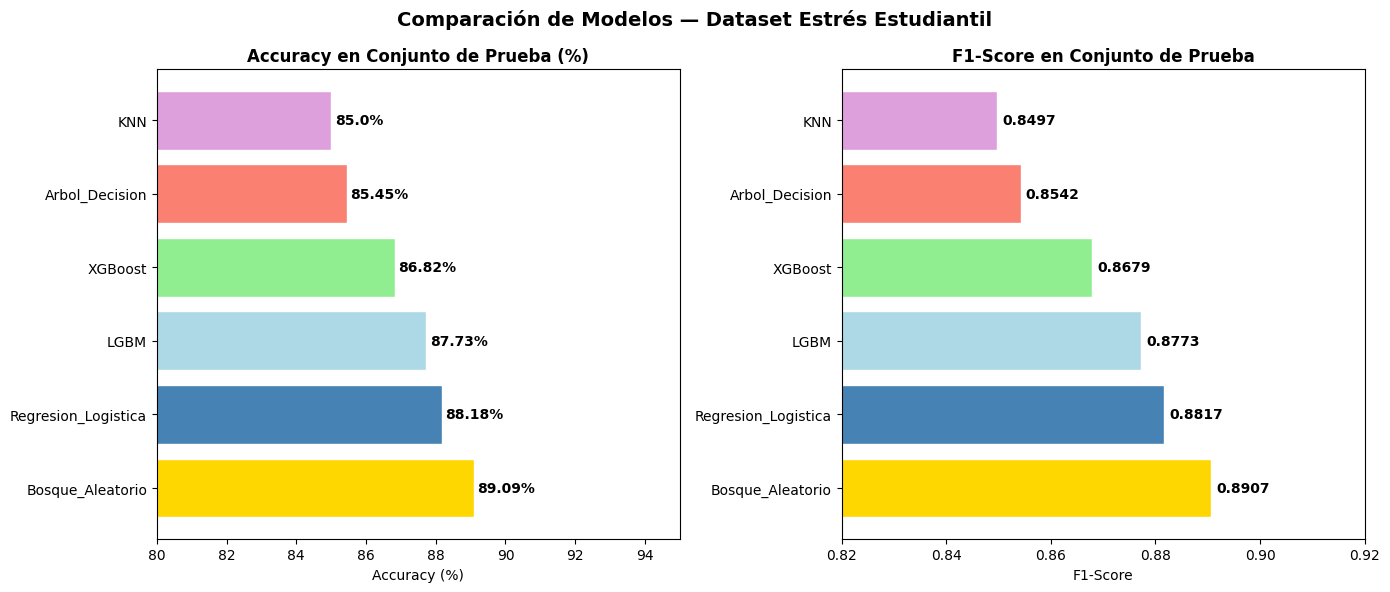

✓ Comparación de modelos visualizada


In [4]:
# ============================================================
# CELDA 4 — Visualización Comparativa de Modelos
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Comparación de Modelos — Dataset Estrés Estudiantil',
             fontweight='bold', fontsize=14)

colores = ['gold', 'steelblue', 'lightblue', 'lightgreen', 'salmon', 'plum']
nombres = df_resultados['Modelo']
accuracy = df_resultados['Accuracy_Prueba (%)']
f1 = df_resultados['F1_Score']

# Gráfico 1 — Accuracy por modelo
bars = axes[0].barh(nombres, accuracy, color=colores, edgecolor='white')
axes[0].set_title('Accuracy en Conjunto de Prueba (%)', fontweight='bold')
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_xlim(80, 95)
for bar, val in zip(bars, accuracy):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontweight='bold')

# Gráfico 2 — F1-Score por modelo
bars2 = axes[1].barh(nombres, f1, color=colores, edgecolor='white')
axes[1].set_title('F1-Score en Conjunto de Prueba', fontweight='bold')
axes[1].set_xlabel('F1-Score')
axes[1].set_xlim(0.82, 0.92)
for bar, val in zip(bars2, f1):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Comparación de modelos visualizada")

In [5]:
# ============================================================
# CELDA 5 — Optimización con GridSearchCV
# ============================================================

from sklearn.model_selection import GridSearchCV
import time

print("=== GRIDSEARCHCV — BÚSQUEDA EXHAUSTIVA ===")
print("Optimizando Bosque_Aleatorio...\n")

# Espacio de búsqueda (Search Space) — combinaciones que GridSearchCV va a probar
param_grid = {
    'n_estimators':      [100, 200, 300],      # Cantidad de árboles (Trees)
    'max_depth':         [None, 10, 20],        # Profundidad máxima (Max Depth)
    'min_samples_split': [2, 5, 10],            # Mínimo de muestras para dividir
    'min_samples_leaf':  [1, 2, 4]             # Mínimo de muestras por hoja (Leaf)
}

inicio = time.time()

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,                    # 5-Fold Cross-Validation
    scoring='accuracy',
    n_jobs=-1,               # Usa todos los núcleos del procesador
    verbose=1
)

grid_search.fit(X_entrenamiento_proc, y_entrenamiento)

fin = time.time()

print(f"\n=== RESULTADOS GRIDSEARCHCV ===")
print(f"Mejores hiperparámetros (Best Hyperparameters): {grid_search.best_params_}")
print(f"Mejor Accuracy CV: {grid_search.best_score_*100:.2f}%")
print(f"Tiempo de búsqueda: {fin-inicio:.1f} segundos")

# Evaluamos en prueba
y_pred_grid = grid_search.best_estimator_.predict(X_prueba_proc)
acc_grid = accuracy_score(y_prueba, y_pred_grid)
f1_grid = f1_score(y_prueba, y_pred_grid, average='weighted')

print(f"\nAccuracy en Prueba: {acc_grid*100:.2f}%")
print(f"F1-Score en Prueba: {f1_grid:.4f}")

=== GRIDSEARCHCV — BÚSQUEDA EXHAUSTIVA ===
Optimizando Bosque_Aleatorio...

Fitting 5 folds for each of 81 candidates, totalling 405 fits

=== RESULTADOS GRIDSEARCHCV ===
Mejores hiperparámetros (Best Hyperparameters): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejor Accuracy CV: 88.18%
Tiempo de búsqueda: 144.2 segundos

Accuracy en Prueba: 89.09%
F1-Score en Prueba: 0.8907


In [6]:
# ============================================================
# CELDA 6 — Optimización con RandomizedSearchCV
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import time

print("=== RANDOMIZEDSEARCHCV — BÚSQUEDA ALEATORIA ===")
print("Optimizando XGBoost...\n")

# Espacio de búsqueda amplio (Wide Search Space)
param_dist = {
    'n_estimators':    randint(100, 500),       # Número de árboles
    'max_depth':       randint(3, 10),           # Profundidad máxima
    'learning_rate':   uniform(0.01, 0.3),       # Tasa de aprendizaje (Learning Rate)
    'subsample':       uniform(0.6, 0.4),        # Fracción de muestras por árbol
    'colsample_bytree': uniform(0.6, 0.4)        # Fracción de columnas por árbol
}

inicio = time.time()

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, verbosity=0),
    param_distributions=param_dist,
    n_iter=50,               # Prueba 50 combinaciones aleatorias
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_entrenamiento_proc, y_entrenamiento)

fin = time.time()

print(f"\n=== RESULTADOS RANDOMIZEDSEARCHCV ===")
print(f"Mejores hiperparámetros: {random_search.best_params_}")
print(f"Mejor Accuracy CV: {random_search.best_score_*100:.2f}%")
print(f"Tiempo de búsqueda: {fin-inicio:.1f} segundos")

# Evaluamos en prueba
y_pred_random = random_search.best_estimator_.predict(X_prueba_proc)
acc_random = accuracy_score(y_prueba, y_pred_random)
f1_random = f1_score(y_prueba, y_pred_random, average='weighted')

print(f"\nAccuracy en Prueba: {acc_random*100:.2f}%")
print(f"F1-Score en Prueba: {f1_random:.4f}")

=== RANDOMIZEDSEARCHCV — BÚSQUEDA ALEATORIA ===
Optimizando XGBoost...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== RESULTADOS RANDOMIZEDSEARCHCV ===
Mejores hiperparámetros: {'colsample_bytree': np.float64(0.9530545372757359), 'learning_rate': np.float64(0.06661213250241381), 'max_depth': 3, 'n_estimators': 198, 'subsample': np.float64(0.8801431319891084)}
Mejor Accuracy CV: 88.98%
Tiempo de búsqueda: 46.2 segundos

Accuracy en Prueba: 87.73%
F1-Score en Prueba: 0.8770


In [7]:
# ============================================================
# CELDA 7 — Optimización con Optuna
# ============================================================

!pip install optuna -q

import optuna
import time
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=== OPTUNA — OPTIMIZACIÓN BAYESIANA ===")
print("Optimizando Bosque_Aleatorio con 50 trials...\n")

# Función objetivo (Objective Function) que Optuna va a maximizar
def objetivo(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }

    modelo = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(modelo, X_entrenamiento_proc, y_entrenamiento,
                             cv=5, scoring='accuracy')
    return scores.mean()

inicio = time.time()

# Creamos el estudio (Study) y lo optimizamos
estudio = optuna.create_study(direction='maximize')
estudio.optimize(objetivo, n_trials=50, show_progress_bar=True)

fin = time.time()

print(f"\n=== RESULTADOS OPTUNA ===")
print(f"Mejores hiperparámetros: {estudio.best_params}")
print(f"Mejor Accuracy CV: {estudio.best_value*100:.2f}%")
print(f"Tiempo de búsqueda: {fin-inicio:.1f} segundos")

# Entrenamos el modelo final con los mejores parámetros
modelo_optuna = RandomForestClassifier(**estudio.best_params, random_state=42)
modelo_optuna.fit(X_entrenamiento_proc, y_entrenamiento)

y_pred_optuna = modelo_optuna.predict(X_prueba_proc)
acc_optuna = accuracy_score(y_prueba, y_pred_optuna)
f1_optuna = f1_score(y_prueba, y_pred_optuna, average='weighted')

print(f"\nAccuracy en Prueba: {acc_optuna*100:.2f}%")
print(f"F1-Score en Prueba: {f1_optuna:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.4 MB/s eta 0:00:00
=== OPTUNA — OPTIMIZACIÓN BAYESIANA ===
Optimizando Bosque_Aleatorio con 50 trials...



  0%|          | 0/50 [00:00<?, ?it/s]


=== RESULTADOS OPTUNA ===
Mejores hiperparámetros: {'n_estimators': 459, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Mejor Accuracy CV: 88.41%
Tiempo de búsqueda: 232.4 segundos

Accuracy en Prueba: 89.55%
F1-Score en Prueba: 0.8954


=== TABLA COMPARATIVA FINAL DE OPTIMIZACIÓN ===
                      Método  Accuracy_Prueba (%)  F1_Score  Tiempo_segundos
     Bosque_Aleatorio (Base)                89.09    0.8907              0.0
                GridSearchCV                89.09    0.8907            144.2
RandomizedSearchCV (XGBoost)                87.73    0.8770             46.2
                      Optuna                89.55    0.8954            232.4

✓ Mejor método: Optuna con 89.55% de Accuracy


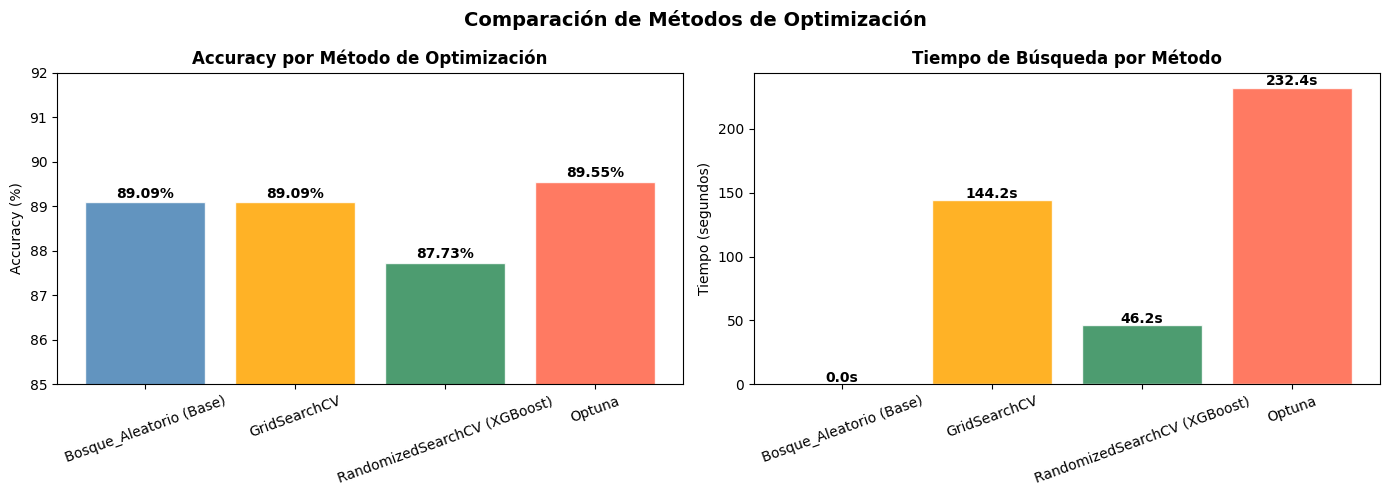

✓ Comparación de optimización visualizada


In [8]:
# ============================================================
# CELDA 8 — Comparación Final de Optimización
# ============================================================

import matplotlib.pyplot as plt

# Tabla resumen de optimización
resultados_optimizacion = pd.DataFrame({
    'Método': [
        'Bosque_Aleatorio (Base)',
        'GridSearchCV',
        'RandomizedSearchCV (XGBoost)',
        'Optuna'
    ],
    'Accuracy_Prueba (%)': [89.09, 89.09, 87.73, 89.55],
    'F1_Score':            [0.8907, 0.8907, 0.8770, 0.8954],
    'Tiempo_segundos':     [0, 144.2, 46.2, 232.4]
})

print("=== TABLA COMPARATIVA FINAL DE OPTIMIZACIÓN ===")
print(resultados_optimizacion.to_string(index=False))
print(f"\n✓ Mejor método: Optuna con 89.55% de Accuracy")

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación de Métodos de Optimización', fontweight='bold', fontsize=14)

colores = ['steelblue', 'orange', 'seagreen', 'tomato']

# Accuracy
axes[0].bar(resultados_optimizacion['Método'],
            resultados_optimizacion['Accuracy_Prueba (%)'],
            color=colores, edgecolor='white', alpha=0.85)
axes[0].set_title('Accuracy por Método de Optimización', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(85, 92)
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(resultados_optimizacion['Accuracy_Prueba (%)']):
    axes[0].text(i, v + 0.1, f'{v}%', ha='center', fontweight='bold')

# Tiempo
axes[1].bar(resultados_optimizacion['Método'],
            resultados_optimizacion['Tiempo_segundos'],
            color=colores, edgecolor='white', alpha=0.85)
axes[1].set_title('Tiempo de Búsqueda por Método', fontweight='bold')
axes[1].set_ylabel('Tiempo (segundos)')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(resultados_optimizacion['Tiempo_segundos']):
    axes[1].text(i, v + 2, f'{v}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparacion_optimizacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Comparación de optimización visualizada")

Preprocesamiento y Optimización

### Dataset Seleccionado
Factores de Estrés Estudiantil (Student Stress Factors)
1.100 estudiantes | 20 variables predictoras | Variable objetivo: Nivel_Estres (Bajo/Medio/Alto)

### Preprocesamiento Aplicado
Se aplicó un Pipeline (Tubería) con ColumnTransformer que incluye StandardScaler
(Escalador Estándar) sobre las 20 variables numéricas. El dataset no requirió
imputación de nulos ni codificación de variables categóricas ya que todas las
variables son numéricas y el dataset está completo. Se realizó Train-Test Split
(División Entrenamiento-Prueba) con 80% entrenamiento (880 registros) y 20%
prueba (220 registros), con estratificación para mantener el balance de clases.

### Comparación de 6 Modelos Iniciales
El Bosque Aleatorio (Random Forest) obtuvo el mejor rendimiento inicial con
89.09% de Accuracy y F1-Score de 0.8907, seguido por Regresión Logística
(88.18%) y LGBM (87.73%). La diferencia entre modelos es pequeña, lo que
indica que el problema tiene una estructura relativamente lineal y bien
definida en los datos.

### Optimización de Hiperparámetros

**GridSearchCV (Búsqueda Exhaustiva en Grilla):**
Probó 81 combinaciones × 5 pliegues = 405 entrenamientos en 144 segundos.
Confirmó que los parámetros por defecto del Bosque Aleatorio ya eran óptimos,
manteniendo 89.09% de Accuracy. Útil para validar que el modelo base estaba
bien configurado.

**RandomizedSearchCV (Búsqueda Aleatoria):**
Probó 50 combinaciones aleatorias sobre XGBoost en solo 46 segundos.
Mejoró XGBoost de 86.82% a 87.73%. Es el método más eficiente en términos
de relación tiempo/mejora, especialmente útil cuando el espacio de búsqueda
es grande.

**Optuna (Optimización Bayesiana):**
Realizó 50 trials aprendiendo de cada resultado anterior en 232 segundos.
Obtuvo el mejor resultado general: 89.55% de Accuracy y F1-Score de 0.8954.
La Optimización Bayesiana (Bayesian Optimization) supera a los métodos
anteriores porque no busca a ciegas sino que construye un modelo probabilístico
del espacio de búsqueda y se enfoca en las zonas más prometedoras.

### Modelo Final Seleccionado
Bosque Aleatorio optimizado con Optuna:
- n_estimators: 459 árboles
- max_depth: 18
- min_samples_split: 5
- min_samples_leaf: 2
- max_features: sqrt
- Accuracy final: 89.55%
- F1-Score final: 0.8954

### Aplicación Práctica
Este modelo es la base técnica de un sistema de detección temprana de estrés
estudiantil especialmente pensado en adolescentes. Dado un estudiante que responde 20 preguntas sobre su bienestar,
el modelo predice con 89.55% de precisión si su nivel de estrés es Bajo,
Medio o Alto. Esto permite a instituciones educativas y /padres y apoderados  activar intervenciones
preventivas como talleres de mindfulness,apoyo psicológico o ajuste de carga
académica antes de que el estrés se cronifique, con respaldo cuantitativo
y reproducible.Ta,bien seri aposible dentro de sus limites y viendo el imapcto de las intervenciones con el mismo modelo ya que si cada estduiante esta identificado podemos tener un histórico de salud mental